# SA/2D Bridge Connection Authoring

Read, modify, and round-trip bridge connection sub-records (routing type 32,
`Conn BR:` blocks) in a HEC-RAS geometry file. This notebook demonstrates
the bridge-specific API on `BaldEagleDamBrk.g03`, which contains 7 bridge
connections and 4 standard connections.

**Scope:** This notebook covers SA/2D and 2D-to-2D bridge connections parsed
by `GeomLateral`. For 1D river/reach bridge structures (`Bridge Culvert-`
blocks), see `GeomBridge`.

In 2D bridges, the offset cross-sections are mesh-generated and share the same
station range, so they align directly at STA 0. This is simpler than 1D bridges
where hand-drawn cross-sections may have different station ranges and require
channel-center alignment.

Bridge sub-records include:
- **Deck geometry** — upstream/downstream station, high-chord, low-chord
- **Bridge cross-sections** — station/elevation inside the bridge opening
- **Piers** — width, elevation, skew per pier
- **Approach cross-sections** — station/elevation outside the bridge
- **Hydraulic coefficients** — drag, contraction, expansion

## Development Mode

In [1]:
#!pip install --upgrade ras-commander

In [2]:
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from ras_commander import RasExamples
from ras_commander.geom import GeomLateral

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

import ras_commander

print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE: loading installed ras-commander


Loaded: <workspace>\ras_commander\__init__.py


## Parameters

In [3]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_SUFFIX = "215_bridge_authoring"
GEOM_FILE_NAME = "BaldEagleDamBrk.g03"
TARGET_CONNECTION = "Highway 120"

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = REPO_ROOT / "working" / "bridge_authoring"
WORK_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Working folder: {WORK_ROOT}")

Working folder: <workspace>\working\bridge_authoring


## Extract And Inspect Connections

In [4]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix=PROJECT_SUFFIX,
)
geom_file = project_path / GEOM_FILE_NAME

print(f"Geometry file: {geom_file.name}")

connections = GeomLateral.get_connections(geom_file)
display(connections[["Name", "Type", "From", "To", "Conn Routing Type", "LinePoints"]])

bridge_conns = connections[connections["Conn Routing Type"] == 32]
print(f"\nBridge connections (routing type 32): {len(bridge_conns)}")
print(f"Standard connections (routing type 1): {len(connections) - len(bridge_conns)}")

Geometry file: BaldEagleDamBrk.g03


,Name,Type,From,To,Conn Routing Type,LinePoints
0,Highway 120,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
1,Highway 150,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
2,Highway 150 Lowe,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
3,Highway 220,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
4,Hwy 220 Upper,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
5,Lower Levee,2D to 2D,BaldEagleCr,BaldEagleCr,1,90
6,Middle Levee,2D to 2D,BaldEagleCr,BaldEagleCr,1,122
7,Mountain Rd,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
8,Railroad Bridge,2D to 2D,BaldEagleCr,BaldEagleCr,32,2
9,Sayers Dam,2D to 2D,BaldEagleCr,BaldEagleCr,1,41



Bridge connections (routing type 32): 7
Standard connections (routing type 1): 4


## Inspect Bridge Sub-Records

Read all bridge-specific data for Highway 120: deck, cross-sections, piers,
and approach cross-sections.

In [5]:
bridge_data = GeomLateral.get_bridge_data(geom_file, TARGET_CONNECTION)

print(f"Bridge params: {bridge_data['bridge_params']}")
print(f"Deck points: {len(bridge_data['deck']['Points'])} "
      f"(NumUp={bridge_data['deck']['NumUp']}, NumDn={bridge_data['deck']['NumDn']})")
print(f"Bridge XS: US={bridge_data['bridge_xs'][0]['NumPoints']}, "
      f"DS={bridge_data['bridge_xs'][1]['NumPoints']} points")
print(f"Piers: {len(bridge_data['piers'])}")
print(f"Approach XS: US={bridge_data['approach_xs'][0]['NumPoints']}, "
      f"DS={bridge_data['approach_xs'][1]['NumPoints']} points")
print(f"Coefficients: {bridge_data['coefficients']}")

Bridge params: ['-1', '0', '-1', '-1', '0']
Deck points: 4 (NumUp=2, NumDn=2)
Bridge XS: US=66, DS=59 points
Piers: 3
Approach XS: US=66, DS=64 points
Coefficients: ['1', '0', '0', '', '', '0.8', '0', '', '0', '']


In [6]:
deck = GeomLateral.get_bridge_deck(geom_file, TARGET_CONNECTION)
print("Deck geometry:")
display(deck)

piers = GeomLateral.get_bridge_piers(geom_file, TARGET_CONNECTION)
print(f"\nPier definitions ({len(piers)} piers):")
display(piers[["PierIndex", "UpstreamStation", "NumUpstreamPoints",
               "UpstreamWidths", "UpstreamElevations"]])

Deck geometry:


,Location,Station,Elevation,LowChord
0,upstream,0.0,580.0,567.0
1,upstream,588.4,595.0,582.0
2,downstream,0.0,580.0,567.0
3,downstream,588.4,595.0,582.0



Pier definitions (3 piers):


,PierIndex,UpstreamStation,NumUpstreamPoints,UpstreamWidths,UpstreamElevations
0,1,110.0,2,"[4.0, 4.0]","[530.0, 575.0]"
1,2,220.0,2,"[4.0, 4.0]","[530.0, 575.0]"
2,3,330.0,2,"[4.0, 4.0]","[530.0, 577.0]"


## Plot Bridge Cross-Sections With Deck And Piers

HEC-RAS-style bridge plots show each face (upstream / downstream) with the
ground profile, deck structure (filled region between high chord and low chord),
and pier outlines. The upstream panel pairs the approach XS with the bridge
opening XS and the upstream deck face; likewise for downstream.

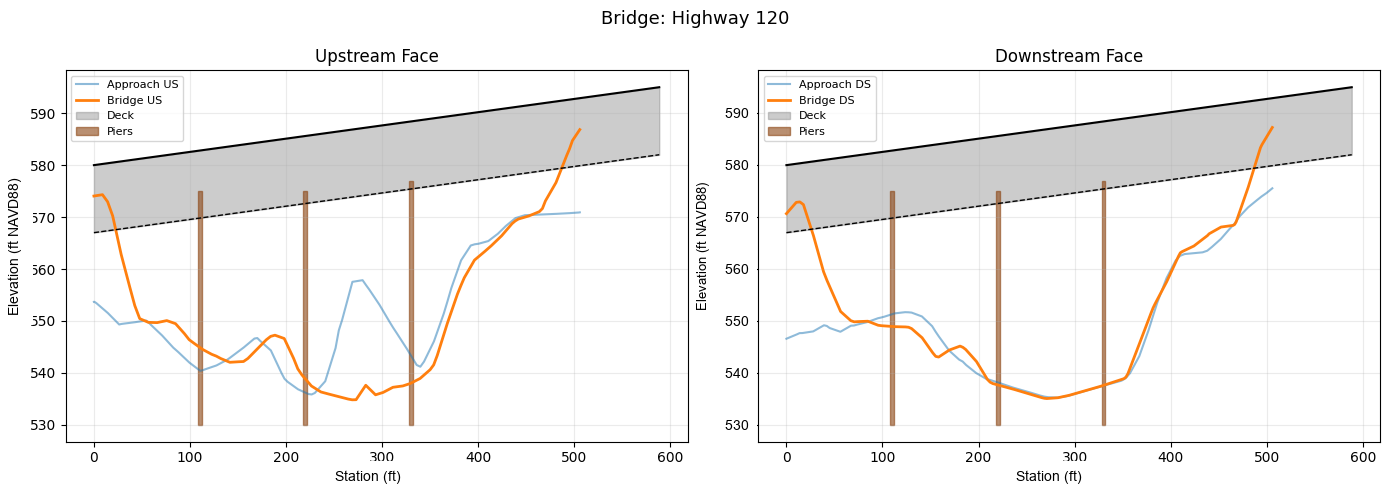

In [7]:
br_us = GeomLateral.get_bridge_xs(geom_file, TARGET_CONNECTION, side=1)
br_ds = GeomLateral.get_bridge_xs(geom_file, TARGET_CONNECTION, side=2)
ap_us = GeomLateral.get_bridge_approach_xs(geom_file, TARGET_CONNECTION, side=1)
ap_ds = GeomLateral.get_bridge_approach_xs(geom_file, TARGET_CONNECTION, side=2)

us_deck = deck[deck["Location"] == "upstream"]
ds_deck = deck[deck["Location"] == "downstream"]

def plot_bridge_face(ax, bridge_xs, approach_xs, face_deck, face_piers, side_label):
    """Plot one face of a bridge: ground profiles, deck polygon, pier outlines."""
    ax.plot(approach_xs["Station"], approach_xs["Elevation"],
            linewidth=1.5, alpha=0.5, label=f"Approach {side_label}")
    ax.plot(bridge_xs["Station"], bridge_xs["Elevation"],
            linewidth=2, label=f"Bridge {side_label}")

    deck_sta = face_deck["Station"].values
    deck_hi = face_deck["Elevation"].values
    deck_lo = face_deck["LowChord"].values
    ax.fill_between(deck_sta, deck_lo, deck_hi,
                    color="gray", alpha=0.4, label="Deck")
    ax.plot(deck_sta, deck_hi, color="black", linewidth=1.5)
    ax.plot(deck_sta, deck_lo, color="black", linewidth=1.0, linestyle="--")

    pier_col = "UpstreamStation" if "US" in side_label else "DownstreamStation"
    w_col = "UpstreamWidths" if "US" in side_label else "DownstreamWidths"
    e_col = "UpstreamElevations" if "US" in side_label else "DownstreamElevations"
    for i, (_, p) in enumerate(face_piers.iterrows()):
        sta = p[pier_col]
        widths = p[w_col]
        elevs = p[e_col]
        left = [sta - w / 2 for w in widths]
        right = [sta + w / 2 for w in widths]
        poly_x = left + right[::-1]
        poly_y = list(elevs) + list(elevs)[::-1]
        ax.fill(poly_x, poly_y, color="saddlebrown", alpha=0.6,
                label="Piers" if i == 0 else None)

    ax.set_xlabel("Station")
    ax.set_ylabel("Elevation")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_bridge_face(axes[0], br_us, ap_us, us_deck, piers, "US")
axes[0].set_title("Upstream Face")

plot_bridge_face(axes[1], br_ds, ap_ds, ds_deck, piers, "DS")
axes[1].set_title("Downstream Face")

fig.suptitle(f"Bridge: {TARGET_CONNECTION}", fontsize=13)
fig.tight_layout()
plt.show()

## Modify Bridge Cross-Section — Channel Region Only

An engineer reviewing the bridge opening plot would identify a station range
to modify (e.g., sediment deposition in the main channel) rather than shifting
the entire cross-section. Here we raise only the channel bed between piers 1
and 3 (stations 100–350) by 1.5 ft.

In [8]:
CHANNEL_STA_MIN = 100.0
CHANNEL_STA_MAX = 350.0
SCOUR_FILL_FT = 1.5

original_br_us = br_us.copy()
modified_br_us = br_us.copy()

in_channel = (
    (modified_br_us["Station"] >= CHANNEL_STA_MIN)
    & (modified_br_us["Station"] <= CHANNEL_STA_MAX)
)
modified_br_us.loc[in_channel, "Elevation"] = (
    modified_br_us.loc[in_channel, "Elevation"] + SCOUR_FILL_FT
)

GeomLateral.set_bridge_xs(
    geom_file, TARGET_CONNECTION,
    modified_br_us, side=1,
    create_backup=False,
)

updated_br_us = GeomLateral.get_bridge_xs(geom_file, TARGET_CONNECTION, side=1)
delta = (updated_br_us["Elevation"] - original_br_us["Elevation"]).round(2)

comparison = pd.DataFrame({
    "Station": original_br_us["Station"],
    "Original": original_br_us["Elevation"],
    "Modified": updated_br_us["Elevation"],
    "Delta": delta,
})
display(comparison[comparison["Delta"] != 0].head(10))

assert all(delta[in_channel] == SCOUR_FILL_FT)
assert all(delta[~in_channel] == 0.0)
print(f"Channel bed raised +{SCOUR_FILL_FT} ft between STA {CHANNEL_STA_MIN}–{CHANNEL_STA_MAX}."
      f" {in_channel.sum()} of {len(delta)} points modified.")

,Station,Original,Modified,Delta
14,103.97,545.73,547.23,1.5
15,113.24,544.51,546.01,1.5
16,122.60,543.58,545.08,1.5
17,127.38,543.23,544.73,1.5
18,132.12,542.76,544.26,1.5
19,141.52,542.04,543.54,1.5
20,151.02,542.15,543.65,1.5
21,155.67,542.19,543.69,1.5
22,160.27,542.78,544.28,1.5
23,179.44,546.38,547.88,1.5


Channel bed raised +1.5 ft between STA 100.0–350.0. 30 of 66 points modified.


## Add A Fourth Pier

The original bridge has 3 piers at stations 110, 220, 330. Add a 4th pier
at station 440.

In [9]:
original_piers = piers.to_dict("records")

new_pier = {
    "PierIndex": 4,
    "Skew": None,
    "UpstreamStation": 440.0,
    "NumUpstreamPoints": 2,
    "DownstreamStation": 440.0,
    "NumDownstreamPoints": 2,
    "UpstreamWidths": [3.0, 3.0],
    "UpstreamElevations": [540.0, 580.0],
    "DownstreamWidths": [3.0, 3.0],
    "DownstreamElevations": [540.0, 580.0],
}

updated_piers = original_piers + [new_pier]

GeomLateral.set_bridge_piers(
    geom_file, TARGET_CONNECTION,
    updated_piers,
    create_backup=False,
)

result_piers = GeomLateral.get_bridge_piers(geom_file, TARGET_CONNECTION)
display(result_piers[["PierIndex", "UpstreamStation", "NumUpstreamPoints",
                      "UpstreamWidths", "UpstreamElevations"]])

assert len(result_piers) == 4
assert result_piers.iloc[3]["UpstreamStation"] == 440.0
print(f"Bridge now has {len(result_piers)} piers.")

,PierIndex,UpstreamStation,NumUpstreamPoints,UpstreamWidths,UpstreamElevations
0,1,110.0,2,"[4.0, 4.0]","[530.0, 575.0]"
1,2,220.0,2,"[4.0, 4.0]","[530.0, 575.0]"
2,3,330.0,2,"[4.0, 4.0]","[530.0, 577.0]"
3,4,440.0,2,"[3.0, 3.0]","[540.0, 580.0]"


Bridge now has 4 piers.


## Raise The Deck

Raise all deck elevations by 2.0 ft.

In [10]:
original_deck = deck.copy()
modified_deck = deck.copy()
modified_deck["Elevation"] = modified_deck["Elevation"] + 2.0
modified_deck["LowChord"] = modified_deck["LowChord"] + 2.0

GeomLateral.set_bridge_deck(
    geom_file, TARGET_CONNECTION,
    modified_deck,
    create_backup=False,
)

updated_deck = GeomLateral.get_bridge_deck(geom_file, TARGET_CONNECTION)
display(updated_deck)

delta_elev = (updated_deck["Elevation"] - original_deck["Elevation"]).round(2)
assert all(delta_elev == 2.0)
print("Deck raised by 2.0 ft.")

,Location,Station,Elevation,LowChord
0,upstream,0.0,582.0,569.0
1,upstream,588.4,597.0,584.0
2,downstream,0.0,582.0,569.0
3,downstream,588.4,597.0,584.0


Deck raised by 2.0 ft.


## Compare Before And After With Deck And Piers

Overlay the original and modified bridge XS against the (now raised) deck and
the updated pier set. The upstream panel highlights the channel-only fill; the
downstream panel shows the new 4th pier.

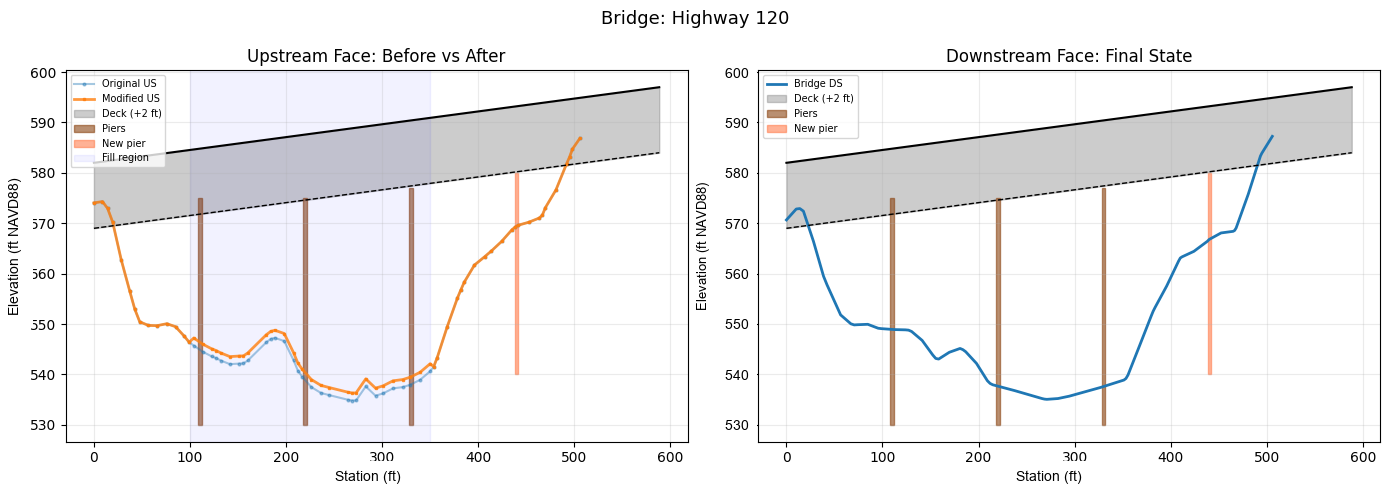

In [11]:
final_br_us = GeomLateral.get_bridge_xs(geom_file, TARGET_CONNECTION, side=1)
final_br_ds = GeomLateral.get_bridge_xs(geom_file, TARGET_CONNECTION, side=2)
final_piers = GeomLateral.get_bridge_piers(geom_file, TARGET_CONNECTION)
final_deck = GeomLateral.get_bridge_deck(geom_file, TARGET_CONNECTION)
final_us_deck = final_deck[final_deck["Location"] == "upstream"]
final_ds_deck = final_deck[final_deck["Location"] == "downstream"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Upstream face: original vs modified XS + raised deck + piers ---
ax = axes[0]
ax.plot(original_br_us["Station"], original_br_us["Elevation"],
        "o-", linewidth=1.5, alpha=0.4, label="Original US", markersize=2)
ax.plot(final_br_us["Station"], final_br_us["Elevation"],
        "s-", linewidth=2, alpha=0.8, label="Modified US", markersize=2)

deck_sta = final_us_deck["Station"].values
ax.fill_between(deck_sta, final_us_deck["LowChord"].values,
                final_us_deck["Elevation"].values,
                color="gray", alpha=0.4, label="Deck (+2 ft)")
ax.plot(deck_sta, final_us_deck["Elevation"].values, color="black", linewidth=1.5)
ax.plot(deck_sta, final_us_deck["LowChord"].values, color="black", linewidth=1.0, linestyle="--")

for i, (_, p) in enumerate(final_piers.iterrows()):
    sta = p["UpstreamStation"]
    widths = p["UpstreamWidths"]
    elevs = p["UpstreamElevations"]
    left = [sta - w / 2 for w in widths]
    right = [sta + w / 2 for w in widths]
    poly_x = left + right[::-1]
    poly_y = list(elevs) + list(elevs)[::-1]
    is_new = p["PierIndex"] == 4
    ax.fill(poly_x, poly_y,
            color="coral" if is_new else "saddlebrown", alpha=0.6,
            label="New pier" if is_new else ("Piers" if i == 0 else None))

ax.axvspan(CHANNEL_STA_MIN, CHANNEL_STA_MAX, color="blue", alpha=0.05, label="Fill region")
ax.set_title("Upstream Face: Before vs After")
ax.set_xlabel("Station")
ax.set_ylabel("Elevation")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, loc="upper left")

# --- Downstream face: XS + raised deck + piers including new pier ---
ax = axes[1]
ax.plot(final_br_ds["Station"], final_br_ds["Elevation"],
        linewidth=2, label="Bridge DS")

deck_sta = final_ds_deck["Station"].values
ax.fill_between(deck_sta, final_ds_deck["LowChord"].values,
                final_ds_deck["Elevation"].values,
                color="gray", alpha=0.4, label="Deck (+2 ft)")
ax.plot(deck_sta, final_ds_deck["Elevation"].values, color="black", linewidth=1.5)
ax.plot(deck_sta, final_ds_deck["LowChord"].values, color="black", linewidth=1.0, linestyle="--")

for i, (_, p) in enumerate(final_piers.iterrows()):
    sta = p["DownstreamStation"]
    widths = p["DownstreamWidths"]
    elevs = p["DownstreamElevations"]
    left = [sta - w / 2 for w in widths]
    right = [sta + w / 2 for w in widths]
    poly_x = left + right[::-1]
    poly_y = list(elevs) + list(elevs)[::-1]
    is_new = p["PierIndex"] == 4
    ax.fill(poly_x, poly_y,
            color="coral" if is_new else "saddlebrown", alpha=0.6,
            label="New pier" if is_new else ("Piers" if i == 0 else None))

ax.set_title("Downstream Face: Final State")
ax.set_xlabel("Station")
ax.set_ylabel("Elevation")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Bridge: {TARGET_CONNECTION}", fontsize=13)
fig.tight_layout()
plt.show()

## Verify All Connections Preserved

In [12]:
final_conns = GeomLateral.get_connections(geom_file)
display(final_conns[["Name", "Type", "Conn Routing Type"]])

assert len(final_conns) == 11
print(f"All {len(final_conns)} connections preserved after modifications.")

,Name,Type,Conn Routing Type
0,Highway 120,2D to 2D,32
1,Highway 150,2D to 2D,32
2,Highway 150 Lowe,2D to 2D,32
3,Highway 220,2D to 2D,32
4,Hwy 220 Upper,2D to 2D,32
5,Lower Levee,2D to 2D,1
6,Middle Levee,2D to 2D,1
7,Mountain Rd,2D to 2D,32
8,Railroad Bridge,2D to 2D,32
9,Sayers Dam,2D to 2D,1


All 11 connections preserved after modifications.


## Summary

In [13]:
summary = pd.DataFrame([{
    "Connection": TARGET_CONNECTION,
    "Conn Routing Type": 32,
    "Channel Fill": f"+{SCOUR_FILL_FT} ft (STA {CHANNEL_STA_MIN}--{CHANNEL_STA_MAX})",
    "Deck Shift": "+2.0 ft",
    "Original Piers": 3,
    "Final Piers": len(final_piers),
    "New Pier Station": 440.0,
    "Connections Preserved": len(final_conns) == 11,
}])
display(summary)
print("SA/2D bridge connection authoring round-trip assertions verified.")

,Connection,Conn Routing Type,Channel Fill,Deck Shift,Original Piers,Final Piers,New Pier Station,Connections Preserved
0,Highway 120,32,+1.5 ft (STA 100.0--350.0),+2.0 ft,3,4,440.0,True


SA/2D bridge connection authoring round-trip assertions verified.


## Validate Write Format With HEC-RAS Geometry Preprocessor

The round-trip assertions above confirm Python can read back what it wrote,
but the ultimate validation is running HEC-RAS on the **modified** geometry.
This catches format issues that round-trip checks cannot: malformed
fixed-width encoding, invalid coordinate precision, or structural corruption
in the bridge connection block.

We extract a **fresh project copy**, apply the same bridge modifications
(channel bed fill, 4th pier, deck raise), then run the HEC-RAS geometry
preprocessor on the plan that uses geometry `.g03`. The preprocessor builds
the 2D mesh, face tables, and bridge connection hydraulic tables — a thorough
format validation without the cost of the full 2D unsteady simulation.

In [14]:
import shutil
import re
import time as _time
from ras_commander import init_ras_project
from ras_commander.geom import GeomPreprocessor

logging.getLogger("ras_commander").setLevel(logging.INFO)

validate_tag = f"validate_{int(_time.time())}"
validate_path = WORK_ROOT / validate_tag
validate_path.mkdir(parents=True, exist_ok=True)

fresh_project = RasExamples.extract_project(PROJECT_NAME, validate_path, suffix="validate")
fresh_geom = fresh_project / GEOM_FILE_NAME

# --------------------------------------------------------------------------
# Apply the SAME bridge modifications to the fresh geometry.
# --------------------------------------------------------------------------

# 1. Raise upstream bridge XS channel bed
br_us_fresh = GeomLateral.get_bridge_xs(fresh_geom, TARGET_CONNECTION, side=1)
in_channel_fresh = (
    (br_us_fresh["Station"] >= CHANNEL_STA_MIN)
    & (br_us_fresh["Station"] <= CHANNEL_STA_MAX)
)
br_us_fresh.loc[in_channel_fresh, "Elevation"] += SCOUR_FILL_FT
GeomLateral.set_bridge_xs(fresh_geom, TARGET_CONNECTION, br_us_fresh, side=1, create_backup=False)

# 2. Add 4th pier
fresh_piers = GeomLateral.get_bridge_piers(fresh_geom, TARGET_CONNECTION)
fresh_piers_list = fresh_piers.to_dict("records") + [new_pier]
GeomLateral.set_bridge_piers(fresh_geom, TARGET_CONNECTION, fresh_piers_list, create_backup=False)

# 3. Raise deck by 2.0 ft
fresh_deck = GeomLateral.get_bridge_deck(fresh_geom, TARGET_CONNECTION)
fresh_deck["Elevation"] = fresh_deck["Elevation"] + 2.0
fresh_deck["LowChord"] = fresh_deck["LowChord"] + 2.0
GeomLateral.set_bridge_deck(fresh_geom, TARGET_CONNECTION, fresh_deck, create_backup=False)

# Verify round-trip on fresh geometry
verify_br = GeomLateral.get_bridge_xs(fresh_geom, TARGET_CONNECTION, side=1)
verify_piers = GeomLateral.get_bridge_piers(fresh_geom, TARGET_CONNECTION)
verify_deck = GeomLateral.get_bridge_deck(fresh_geom, TARGET_CONNECTION)
assert all((verify_br["Elevation"] - br_us_fresh["Elevation"]).abs() < 0.01)
assert len(verify_piers) == 4
assert verify_piers.iloc[3]["UpstreamStation"] == 440.0
print(f"All modifications applied and verified on fresh geometry")

# --------------------------------------------------------------------------
# Run geometry preprocessor on the MODIFIED geometry.
# --------------------------------------------------------------------------

ras_val = init_ras_project(fresh_project, "7.0")
plans_using_g03 = ras_val.plan_df[ras_val.plan_df["Geom File"] == "03"]
assert not plans_using_g03.empty, "No plan found using geometry file .g03"
plan_number = plans_using_g03.iloc[0]["plan_number"]

plan_file = fresh_project / f"BaldEagleDamBrk.p{plan_number.zfill(2)}"
plan_text = plan_file.read_text()
plan_text = re.sub(r"Program Version=.*", f"Program Version={ras_val.ras_version}", plan_text)
plan_file.write_text(plan_text)

fresh_geom_text = fresh_geom.read_text()
fresh_geom_text = re.sub(r"Program Version=.*", f"Program Version={ras_val.ras_version}", fresh_geom_text)
fresh_geom.write_text(fresh_geom_text)
print(f"\nUpdated plan {plan_number} and geometry Program Version to {ras_val.ras_version}")

print(f"Running geometry preprocessor for Plan {plan_number} on MODIFIED geometry "
      f"(channel +{SCOUR_FILL_FT} ft, deck +2 ft, 4th pier)...")
preprocess_result = GeomPreprocessor.run_geometry_preprocessor(
    plan_number,
    ras_object=ras_val,
    max_wait=500,
    force=True,
    geometry_only=True,
)

assert preprocess_result.success, (
    f"Geometry preprocessor failed: {preprocess_result.error}\n"
    f"Errors: {preprocess_result.error_count}, First: {preprocess_result.first_error_line}"
)

print(f"\n{'='*70}")
print(f"VALIDATION RESULT")
print(f"{'='*70}")
print(f"  Geometry file:    {fresh_geom.name} (MODIFIED)")
print(f"  Bridge XS:        Channel bed +{SCOUR_FILL_FT} ft (STA {CHANNEL_STA_MIN}--{CHANNEL_STA_MAX})")
print(f"  Deck:             +2.0 ft (high chord and low chord)")
print(f"  Piers:            4 (added pier at STA 440)")
print(f"  HEC-RAS version:  {ras_val.ras_version}")
print(f"  Preprocessor:     PASSED ({preprocess_result.elapsed_seconds:.0f}s)")
print(f"  Errors:           {preprocess_result.error_count}")
print(f"  Warnings:         {preprocess_result.warning_count}")
print(f"{'='*70}")
print(f"  set_bridge_xs write format:    VALIDATED")
print(f"  set_bridge_piers write format: VALIDATED")
print(f"  set_bridge_deck write format:  VALIDATED")
print(f"{'='*70}")

All modifications applied and verified on fresh geometry



Updated plan 05 and geometry Program Version to 7.0
Running geometry preprocessor for Plan 05 on MODIFIED geometry (channel +1.5 ft, deck +2 ft, 4th pier)...



VALIDATION RESULT
  Geometry file:    BaldEagleDamBrk.g03 (MODIFIED)
  Bridge XS:        Channel bed +1.5 ft (STA 100.0--350.0)
  Deck:             +2.0 ft (high chord and low chord)
  Piers:            4 (added pier at STA 440)
  HEC-RAS version:  7.0
  Preprocessor:     PASSED (15s)
  Errors:           0
  Warnings:         0
  set_bridge_xs write format:    VALIDATED
  set_bridge_piers write format: VALIDATED
  set_bridge_deck write format:  VALIDATED


## Verify Bridge Connection In Preprocessed Geometry

The geometry preprocessor validates the geometry format by building the 2D
mesh, face tables, and bridge connection hydraulic tables. Confirm the
preprocessor created its artifact files and that the target bridge connection
is still intact in the modified geometry text file.

In [15]:
final_connections = GeomLateral.get_connections(fresh_geom)
bridge_conns_final = final_connections[final_connections["Conn Routing Type"] == 32]

assert TARGET_CONNECTION in final_connections["Name"].values, (
    f"'{TARGET_CONNECTION}' not found in modified geometry connections"
)

print(f"Connections in modified geometry: {len(final_connections)}")
print(f"Bridge connections (routing type 32): {len(bridge_conns_final)}")
display(final_connections[["Name", "Type", "Conn Routing Type"]])

artifact_count = len(preprocess_result.artifact_paths)
artifact_names = [p.name for p in preprocess_result.artifact_paths] if artifact_count > 0 else []

conn_verification = pd.DataFrame([{
    "Target Connection": TARGET_CONNECTION,
    "Present In Geometry": TARGET_CONNECTION in final_connections["Name"].values,
    "Total Connections": len(final_connections),
    "Bridge Connections": len(bridge_conns_final),
    "Preprocessor Success": bool(preprocess_result.success),
    "Preprocessor Artifacts": artifact_count,
    "Elapsed (s)": round(preprocess_result.elapsed_seconds, 1),
    "Errors": preprocess_result.error_count,
    "Warnings": preprocess_result.warning_count,
}])
display(conn_verification)

print(f"\n{'='*70}")
print(f"STRUCTURE VALIDATION: '{TARGET_CONNECTION}' bridge connection geometry preprocessed")
print(f"  Geometry preprocessor:  PASSED ({preprocess_result.elapsed_seconds:.0f}s)")
print(f"  Artifacts created:      {artifact_count}")
print(f"  Connection preserved:   {TARGET_CONNECTION} (routing type 32)")
print(f"  Modified geometry accepted by HEC-RAS {ras_val.ras_version}")
print(f"{'='*70}")

Connections in modified geometry: 11
Bridge connections (routing type 32): 7


,Name,Type,Conn Routing Type
0,Highway 120,2D to 2D,32
1,Highway 150,2D to 2D,32
2,Highway 150 Lowe,2D to 2D,32
3,Highway 220,2D to 2D,32
4,Hwy 220 Upper,2D to 2D,32
5,Lower Levee,2D to 2D,1
6,Middle Levee,2D to 2D,1
7,Mountain Rd,2D to 2D,32
8,Railroad Bridge,2D to 2D,32
9,Sayers Dam,2D to 2D,1


,Target Connection,Present In Geometry,Total Connections,Bridge Connections,Preprocessor Success,Preprocessor Artifacts,Elapsed (s),Errors,Warnings
0,Highway 120,True,11,7,True,3,15.3,0,0



STRUCTURE VALIDATION: 'Highway 120' bridge connection geometry preprocessed
  Geometry preprocessor:  PASSED (15s)
  Artifacts created:      3
  Connection preserved:   Highway 120 (routing type 32)
  Modified geometry accepted by HEC-RAS 7.0
